In [1]:
# ============================================================
# CELL 1 — FASTF1 SETUP & LOAD MONACO 2024
# ============================================================

import fastf1
import fastf1.plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# --- Enable FastF1 cache (speeds up repeated loads massively) ---
import os
cache_path = '../cache'
os.makedirs(cache_path, exist_ok=True)
fastf1.Cache.enable_cache(cache_path)
print(f"✅ Cache enabled at: {cache_path}")

# --- Load Monaco 2024 Race Session ---
print("\n⏳ Loading Monaco 2024 Race session (first load may take 1-2 mins)...")
session = fastf1.get_session(2024, 'Monaco', 'R')
session.load()
print("✅ Session loaded successfully.")

# --- Session Info ---
print(f"\n{'='*50}")
print(f"  Event    : {session.event['EventName']}")
print(f"  Circuit  : {session.event['Location']}")
print(f"  Date     : {session.event['EventDate'].strftime('%d %b %Y')}")
print(f"  Season   : 2024")
print(f"{'='*50}")

# --- Get top 5 finishers ---
results = session.results[['DriverNumber', 'Abbreviation',
                            'FullName', 'TeamName',
                            'Position', 'Points']].copy()
results = results.sort_values('Position').head(5)

print("\n  Top 5 Finishers:")
print(f"  {'Pos':<5} {'Driver':<25} {'Team':<25} {'Pts'}")
print(f"  {'-'*60}")
for _, row in results.iterrows():
    print(f"  {int(row['Position']):<5} {row['FullName']:<25} {row['TeamName']:<25} {int(row['Points'])}")

print(f"\n✅ Cell 1 complete - Monaco 2024 session ready.")

✅ Cache enabled at: ../cache

⏳ Loading Monaco 2024 Race session (first load may take 1-2 mins)...


core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['16', '81', '55', '4', '63', '1', '44', '22', '23', '10', '14', '3', '77', '18', '2', '24', '31', '11', '27', '20']


✅ Session loaded successfully.

  Event    : Monaco Grand Prix
  Circuit  : Monaco
  Date     : 26 May 2024
  Season   : 2024

  Top 5 Finishers:
  Pos   Driver                    Team                      Pts
  ------------------------------------------------------------
  1     Charles Leclerc           Ferrari                   25
  2     Oscar Piastri             McLaren                   18
  3     Carlos Sainz              Ferrari                   15
  4     Lando Norris              McLaren                   12
  5     George Russell            Mercedes                  10

✅ Cell 1 complete - Monaco 2024 session ready.


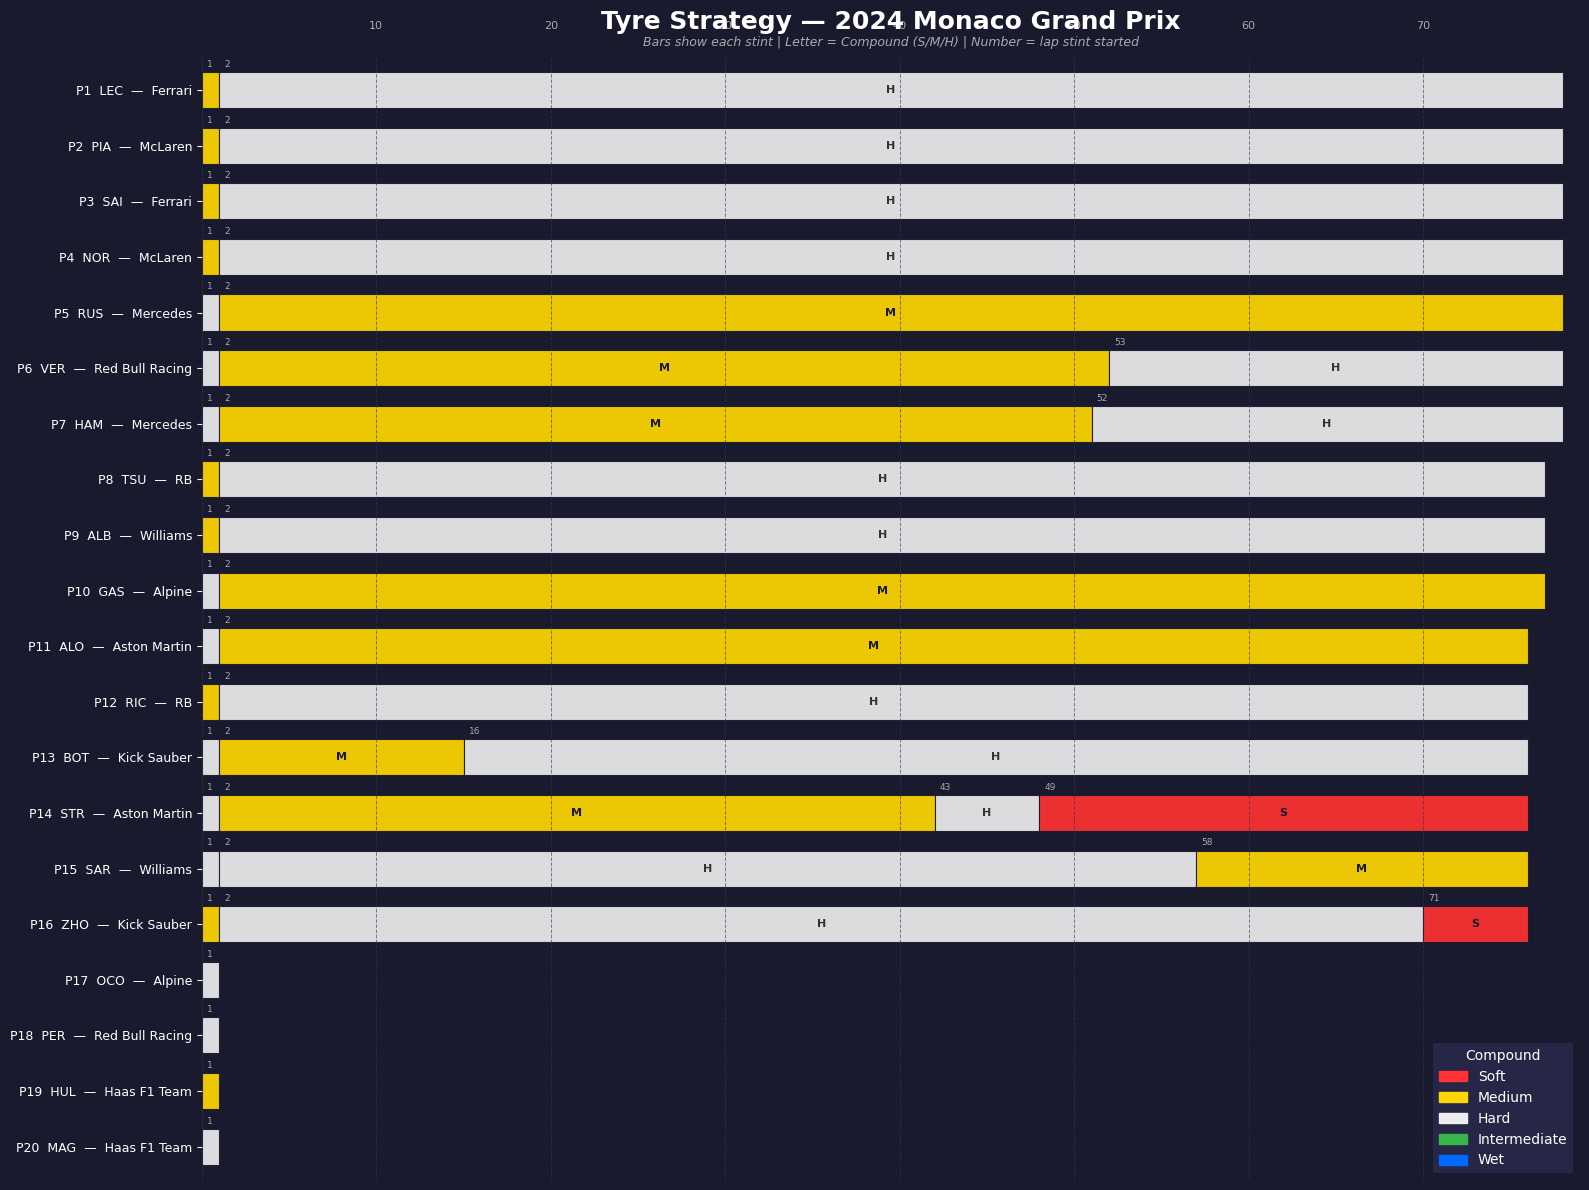

✅ Cell 2 complete — Tyre Strategy chart saved.


In [2]:
# ============================================================
# CELL 2 — TYRE STRATEGY VISUALISATION MONACO 2024
# ============================================================

# --- Tyre compound colours (official Pirelli colours) ---
compound_colors = {
    'SOFT':     '#FF3333',
    'MEDIUM':   '#FFD700',
    'HARD':     '#EEEEEE',
    'INTER':    '#39B54A',
    'WET':      '#0067FF',
    'UNKNOWN':  '#888888',
}

# --- Get all laps with tyre data ---
laps = session.laps.copy()

# --- Get all drivers sorted by finishing position ---
all_results = session.results[['Abbreviation', 'FullName',
                                'TeamName', 'Position']].copy()
all_results = all_results.sort_values('Position')

# Only keep classified finishers (Position is numeric)
all_results = all_results[pd.to_numeric(
    all_results['Position'], errors='coerce').notna()
]
all_results['Position'] = all_results['Position'].astype(int)

# --- Build stint data per driver ---
stint_data = []

for _, driver_row in all_results.iterrows():
    drv = driver_row['Abbreviation']
    drv_laps = laps[laps['Driver'] == drv].copy()

    if drv_laps.empty:
        continue

    # Group by stint number
    drv_laps['Stint'] = drv_laps['Stint'].fillna(1).astype(int)
    stints = drv_laps.groupby('Stint').agg(
        LapStart  = ('LapNumber', 'min'),
        LapEnd    = ('LapNumber', 'max'),
        Compound  = ('Compound', 'first')
    ).reset_index()

    for _, stint in stints.iterrows():
        stint_data.append({
            'Driver':    drv,
            'FullName':  driver_row['FullName'],
            'Team':      driver_row['TeamName'],
            'Position':  driver_row['Position'],
            'Stint':     int(stint['Stint']),
            'LapStart':  int(stint['LapStart']),
            'LapEnd':    int(stint['LapEnd']),
            'Compound':  str(stint['Compound']).upper(),
            'StintLen':  int(stint['LapEnd']) - int(stint['LapStart']) + 1,
        })

stint_df = pd.DataFrame(stint_data)
total_laps = int(laps['LapNumber'].max())

# --- Build driver label (Position. ABB — Team) ---
stint_df['Label'] = stint_df.apply(
    lambda r: f"P{r['Position']}  {r['Driver']}  —  {r['Team']}", axis=1
)

# Ordered list of labels by position
driver_labels = (
    stint_df[['Position', 'Label']]
    .drop_duplicates()
    .sort_values('Position', ascending=False)['Label']
    .tolist()
)

# ============================================================
# PLOT
# ============================================================
fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('#1a1a2e')
ax.set_facecolor('#1a1a2e')

y_positions = {label: i for i, label in enumerate(driver_labels)}

for _, row in stint_df.iterrows():
    compound  = row['Compound']
    color     = compound_colors.get(compound, '#888888')
    y         = y_positions[row['Label']]
    width     = row['StintLen']
    x_start   = row['LapStart'] - 1

    # Main stint bar
    ax.barh(
        y, width, left=x_start,
        color=color, edgecolor='#1a1a2e',
        linewidth=0.8, height=0.65,
        alpha=0.92
    )

    # Compound label inside bar if wide enough
    if width >= 4:
        ax.text(
            x_start + width / 2, y,
            compound[:1],          # S / M / H / I / W
            ha='center', va='center',
            fontsize=8, fontweight='bold',
            color='#1a1a2e' if compound != 'HARD' else '#333333'
        )

    # Lap number at start of each stint
    ax.text(
        x_start + 0.3, y + 0.38,
        str(row['LapStart']),
        ha='left', va='bottom',
        fontsize=6.5, color='#aaaaaa'
    )

# --- Lap count vertical gridlines every 10 laps ---
for lap in range(0, total_laps + 1, 10):
    ax.axvline(x=lap, color='#333355', linewidth=0.7,
               linestyle='--', alpha=0.6)
    if lap > 0:
        ax.text(lap, len(driver_labels) + 0.1,
                str(lap), ha='center', fontsize=8,
                color='#aaaaaa')

# --- Styling ---
ax.set_yticks(range(len(driver_labels)))
ax.set_yticklabels(driver_labels, fontsize=9.5, color='white')
ax.set_xlabel('Lap Number', fontsize=12, color='#aaaaaa')
ax.set_xlim(0, total_laps + 1)
ax.set_ylim(-0.6, len(driver_labels) - 0.4)
ax.spines[['top', 'right', 'left', 'bottom']].set_visible(False)
ax.tick_params(colors='white', labelsize=9)
ax.xaxis.set_visible(False)

ax.set_title('Tyre Strategy — 2024 Monaco Grand Prix',
             fontsize=18, fontweight='bold',
             color='white', pad=20)
ax.text(0.5, 1.01,
        'Bars show each stint | Letter = Compound (S/M/H) | Number = lap stint started',
        transform=ax.transAxes, fontsize=9,
        color='#aaaaaa', ha='center', style='italic')

# --- Legend ---
legend_patches = [
    mpatches.Patch(color=compound_colors['SOFT'],   label='Soft'),
    mpatches.Patch(color=compound_colors['MEDIUM'], label='Medium'),
    mpatches.Patch(color=compound_colors['HARD'],   label='Hard'),
    mpatches.Patch(color=compound_colors['INTER'],  label='Intermediate'),
    mpatches.Patch(color=compound_colors['WET'],    label='Wet'),
]
ax.legend(
    handles=legend_patches,
    loc='lower right',
    facecolor='#2a2a4e',
    edgecolor='none',
    labelcolor='white',
    fontsize=10,
    title='Compound',
    title_fontsize=10
)
ax.legend_.get_title().set_color('white')

plt.tight_layout()
plt.savefig('monaco_2024_tyre_strategy.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Cell 2 complete — Tyre Strategy chart saved.")